# NAME: CHAMORRO_ROSERO_RONALDO_LUIS

# Problem 1. Thermodynamics of ideal and real gases

The equation of state (EOS) for ideal gases is given by:

$$P\,V = n\,R\,T$$

where:
- $P$ is the pressure,
- $V$ is the volume,
- $T$ is the temperature,
- $R = 0.08314\,\rm L\,bar/(mol\,K)$ is the ideal gas constant,
- $n$ is the number of moles.

On the other hand, real gases can be modeled with the van der Waals equation (EOS):

$$\left(P + \frac{n^2 a}{V^2}\right)(V - n\,b) = n\,R\,T$$

where $a$ and $b$ are constants that depend on the gas composition. The table below shows typical values of these constants for 6 gases:

| Gas             | $a\,\rm (L^2\,bar/mol^2)$ | $b\,\rm (L/mol)$ |
|-----------------|---------------------|-----------------|
| Hydrogen ($\rm H_2$)   | 0.248               | 0.0266          |
| Nitrogen ($\rm N_2$)   | 1.370               | 0.0387          |
| Oxygen ($\rm O_2$)     | 1.382               | 0.0319          |
| Chlorine ($\rm Cl_2$)  | 6.579               | 0.0562          |
| Carbon Dioxide ($\rm CO_2$) | 3.640          | 0.0427          |
| Methane ($\rm CH_4$)   | 2.283             | 0.0428          |


##### Reference: https://en.wikipedia.org/wiki/Van_der_Waals_constants_(data_page)

### Coding tasks:

#### Python basics:

**(a)** Create a python function that reads $n$, $T$, $V$, $a$, $b$ and returns a two-element tuple with the thermal pressures $P$, calculated with the ideal gas equation and the van der Waals equation.

**(b)** Define a python dictionary containing the identifiers of all 6 gases as "keys" with their respective $a$ and $b$ constants as elements.

#### Pressure-Volume (PV) plots:

**(c)** Generate a 1D volume vector covering the range from $0.5$ to $5\,\rm L$, and fix the number of moles at $n=1\,\rm mol$ and the temperature of the gas at $T=298\,\rm K$.

**(d)** Using the values of $a$ and $b$ from the dictionary in point (b), and the inputs in defined (c), call the function created in point (a) to obtain a set of pressure arrays, $P$, with both equations of state for each gas. (**Hint:** a for loop can help access the dictionary elements).

**(e)** Use matplotlib to make a high-quality, labeled, multi-panel figure of the thermal pressure (calculated with both EOS) of all 6 gases as a function of volume. The plot should have $P$ on the Y axis and $V$ on the X axis.

#### Temperature surfaces on the PV plane:

**(f)** Now, we want to represent the gas temperature surfaces on the PV plane. Create a new python function that reads $n$, $P$, $V$, $a$, $b$ and returns a two-element tuple with the temperatures $T$, calculated with the ideal gas equation and the van der Waals equation. 

**(g)** Create a 2D pressure-volume (PV) meshgrid using appropriate vectors for thermal pressures and volumes.

**(h)** Use matplotlib to make two high-quality, labeled, multi-panel figures of the 2D temperatures (calculated with both EOS) of all 6 gases as a function of pressure and volume. The first figure should show 3D visualisations of the temperature surface. The second figure should show 2D projections of the temperature surface onto the PV plane. All the plots should have $P$ on the Y axis, $V$ on the X axis, and $T$ on the Z axis. 

### Analysis questions:

**(i)** Briefly explain, what do the $a$ and $b$ constants in the real gas EOS represent physically?

**(j)** Based on the figures you made, what differences do you see between ideal and real gases? When do they coincide or differ?


In [3]:
import scipy.constants as ct
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import scipy.optimize as opt

# SOLUTION

## Solution a)

In [5]:
def thermal_pressures(n, T, V, a, b):
    PIG = (n*(ct.R/100)*T)/V                           #ct.R is the ideal gas constant
    PVW = (n*(ct.R/100)*T)/(V-(n*b)) - (a*(n)**2)/((V)**2)
    return PIG, PVW

## Solution b)

In [8]:
dicVWC = {"Hydrogen": (0.248, 0.0266), "Nitrogen": (1.370, 0.0387), "Oxygen":(1.382, 0.0319),
         "Chlorine": (6.579, 0.0562), "Carbon Dioxide": (3.640, 0.0427), "Methane": (2.283, 0.0428)}

## Solution c)

In [11]:
vecPV = np.linspace(0.5, 5, 100) #last number I chosed myself
n = 1
T = 298

#print(vecPV)

## Solution d)

In [14]:
dicP = {}    #Final values

for key, value in dicVWC.items(): #values in pairs
    a = value[0]
    b = value[1]
    result = thermal_pressures(n, T, vecPV, a, b)
    #print(result)
    dicP[key] = result
#print(dicP)

## Solution e)

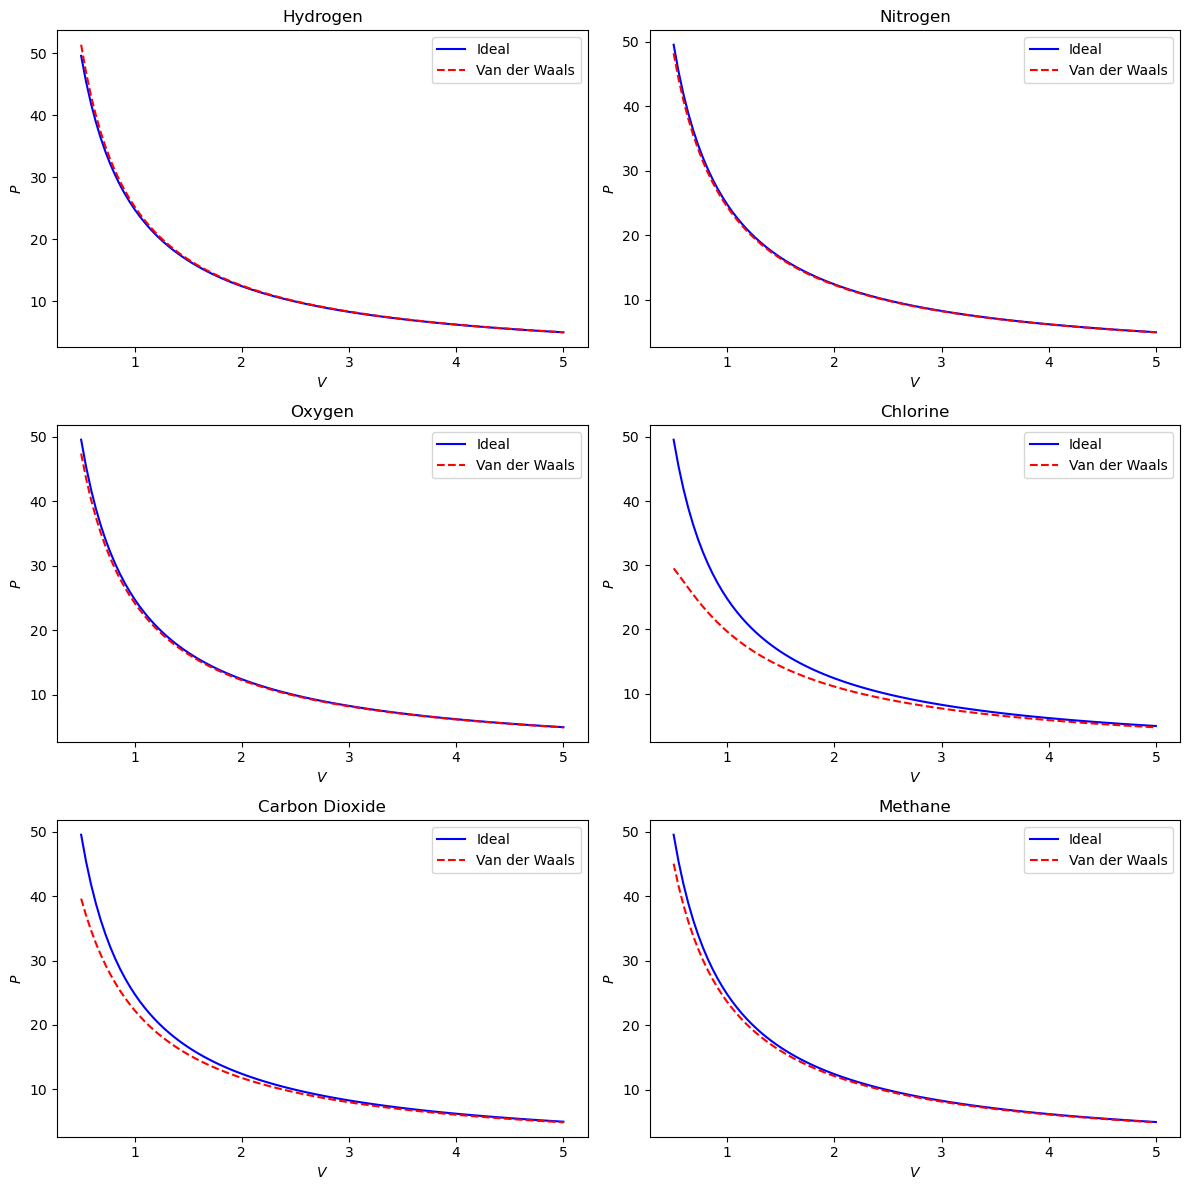

In [17]:

i = -1
plt.figure(figsize=(12, 12))
for key, value in dicP.items():
    i += 1
    result1 = value[0]
    result2 = value[1]
 
    #print(i) 


    
    plt.subplot(3, 2, i+1)
    
    plt.plot(vecPV, result1, label="Ideal", linestyle= "-", color="blue")
    plt.plot(vecPV, result2, label="Van der Waals", linestyle= "--", color= "red")
    plt.legend()
    plt.title(key)
    
    plt.xlabel(r"$V$")
    plt.ylabel(r"$P$")
    plt.tight_layout() #to separate
    

#plt.savefig("Thermodynamics_of_ideal_and_real_gases.svg")
plt.show()

## Solution f)

In [20]:
def temperature_surfaces(n, P, V, a, b):
    TVW = (1/(n*ct.R/100)) *(P + ((n**2*a)/(V**2)))*(V-(n*b))
    TIG = ((P*V)/(n*(ct.R/100)))
    return TVW, TIG

## Solution g)

In [23]:
vecP = np.linspace(5, 50, 200)
vecV = np.linspace(0.5, 5, 200)

x_2d, y_2d = np.meshgrid(vecV, vecP)


## Solution h)

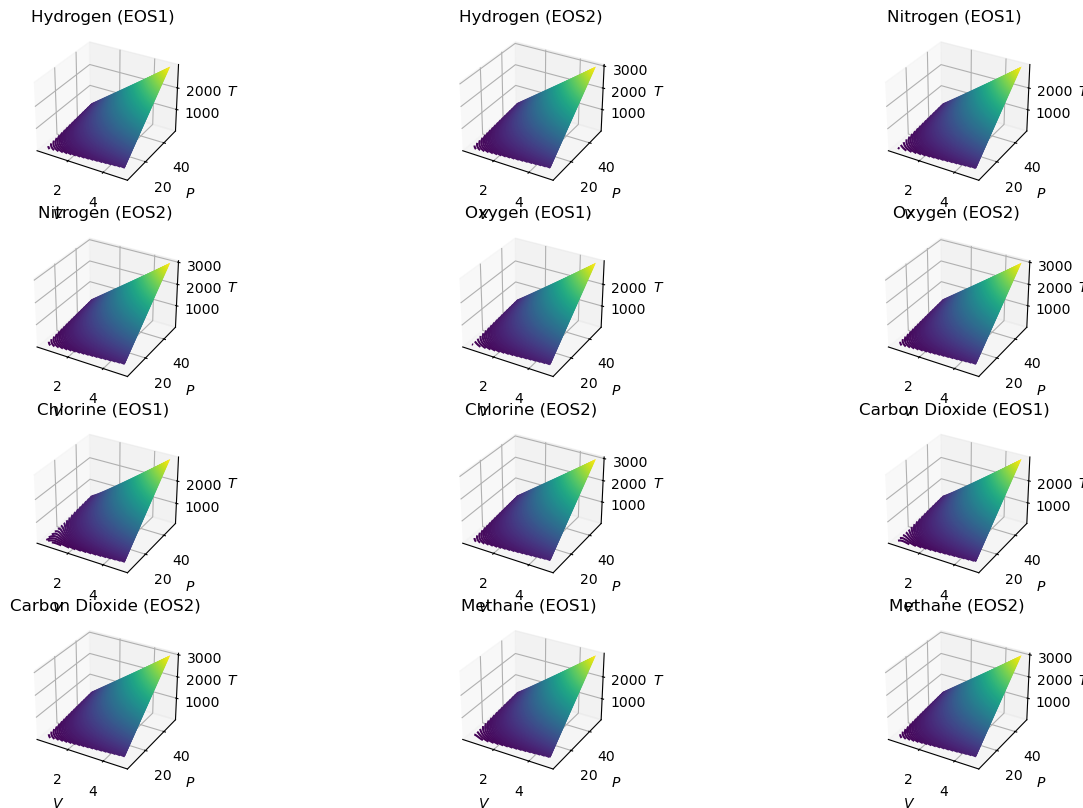

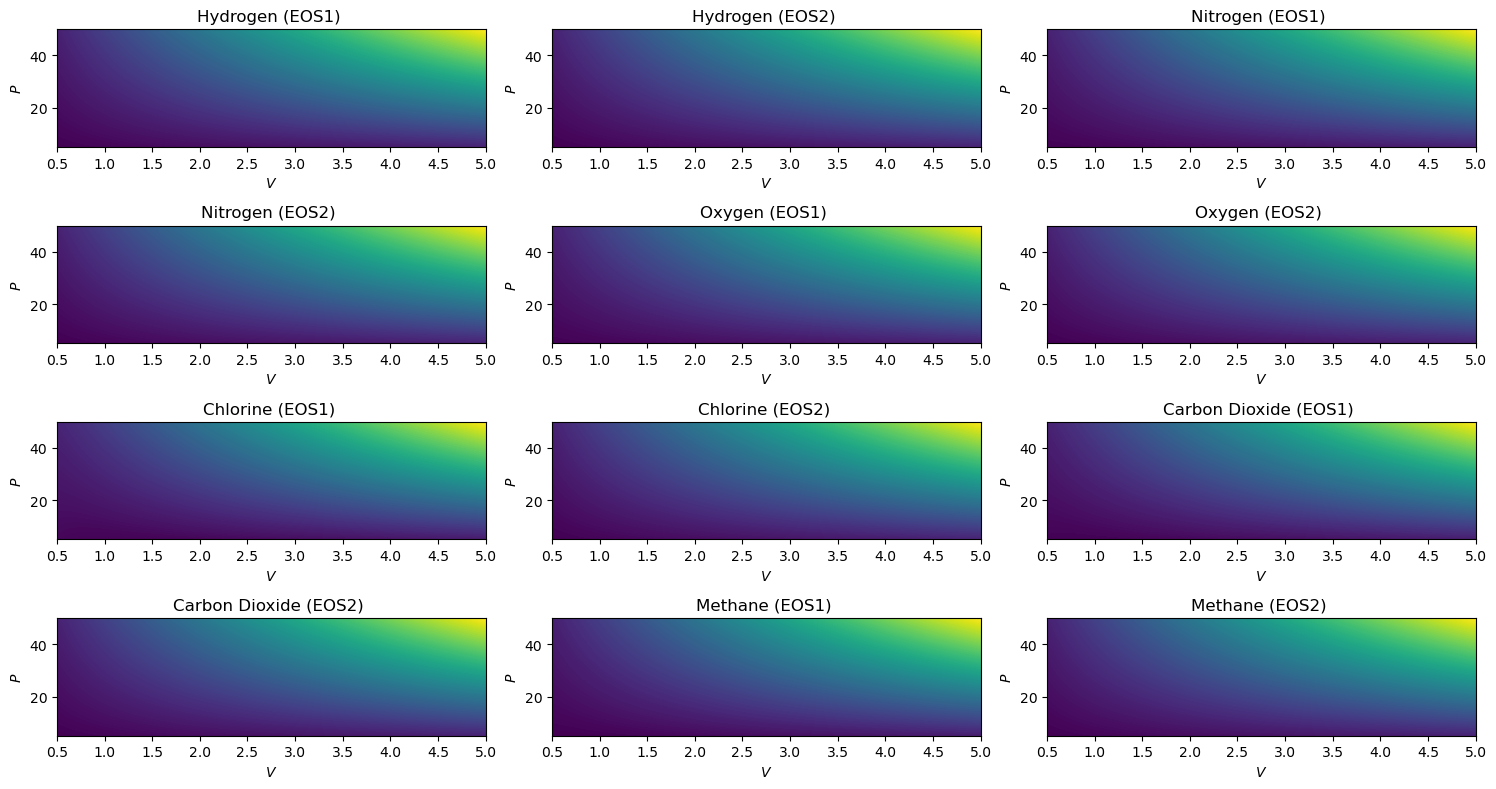

In [26]:
plt.close('all')


dicT = {}
for key, value in dicVWC.items():
    ah = value[0]
    bh = value[1]
    dicT[key] = temperature_surfaces(n, y_2d, x_2d, ah, bh)



i = -1
fig = plt.figure(figsize=(15, 8))
for key, value in dicT.items():
    z_2d1 = value[0]
    z_2d2 = value[1]

    i += 1
    ax = plt.subplot(4, 3, i+1, projection="3d")
    ax.contour3D(x_2d, y_2d, z_2d1, 200)
    ax.set_title(f'{key} (EOS1) ')
    ax.set_xlabel(r"$V$")
    ax.set_ylabel(r"$P$")
    ax.set_zlabel(r"$T$")

    i += 1
    ax = plt.subplot(4, 3, i+1, projection="3d")
    ax.contour3D(x_2d, y_2d, z_2d2, 200)
    ax.set_title(f'{key} (EOS2)')
    ax.set_xlabel(r"$V$")
    ax.set_ylabel(r"$P$")
    ax.set_zlabel(r"$T$")

#plt.savefig("3DSURFACES.svg")
plt.tight_layout()
plt.show()


# 2D PROJECTIONS
k = -1
fig = plt.figure(figsize=(15, 8))
for key, value in dicT.items():
    z_2d1 = value[0]
    z_2d2 = value[1]

    k += 1
    ax = plt.subplot(4, 3, k+1)
    ax.contourf(x_2d, y_2d, z_2d1, 200)
    ax.set_title(f'{key} (EOS1) ')
    ax.set_xlabel(r"$V$")
    ax.set_ylabel(r"$P$")

    k += 1
    ax = plt.subplot(4, 3, k+1)
    ax.contourf(x_2d, y_2d, z_2d2, 200)
    ax.set_title(f'{key} (EOS2) ')
    ax.set_xlabel(r"$V$")
    ax.set_ylabel(r"$P$")

#plt.savefig("2DPROJECTIONS.svg")
plt.tight_layout()
plt.show()

## Solution i)

The term a corrects for the attraction that molecules have, so they hit the walls of the container  Then, to fix this, we need to subtract from the volume (-nb) to represent the real volume the particles have.

## Solution j)

Ideal and real gases converge at large V, where the correction terms vanish, and diverge at small V, where nb and an²/V² matter more. H₂ (smallest a, b) stays closest to ideal Cl₂/CO₂ (larger a, b) deviate most.

# Problem 2. Exploring Statistics and Confidence Levels

Imagine that you are provided with two datasets (in the following data files), where experimenters took $N=10^4$ measurements of two different quantities:

Sample $1$: https://github.com/wbandabarragan/physics-teaching-data/blob/main/1D-data/sample1_hres.dat

Sample $2$: https://github.com/wbandabarragan/physics-teaching-data/blob/main/1D-data/sample2_hres.dat

The goal of this exercise is to determine how the data points in each sample are distributed, to visualise confidence intervals, and to quantify p-values after carrying out regressions.

### Coding tasks:

**(a)** Create python functions to load and visualise the datasets. Make histograms of each dataset and examine the shape of the distributions.

**(b)** Based on the histogram plots, propose, write down, and fit candidate statistical distributions. Report the results in plots containing the histograms and the best-fit functions.

**(c)** Calculate the Cumulative Distribution Function (CDF) and perform goodness-of-fit analyses using the Kolmogorov-Smirnov (KS) test. Determine and report the KS statistic and the resulting p-values.

**(d)** Calculate the mean of each dataset. Then, compute confidence intervals corresponding to $1\sigma$, $2\sigma$, and $3\sigma$. Report the $1\sigma$ errors (upper and lower) for each dataset explicitly.

**(e)** Plot the histograms overlaid with the best-fit probability density functions. Add shaded regions to illustrate the $1\sigma$, $2\sigma$, and $3\sigma$ confidence intervals.


### Analysis questions:

**(f)** What do the KS and p-values computed in (c) indicate for each data sample?

**(g)** Comment on the differences in the shapes of the confidence intervals between the two datasets and how this relates to uncertainties.

# SOLUTION

## Solution a)

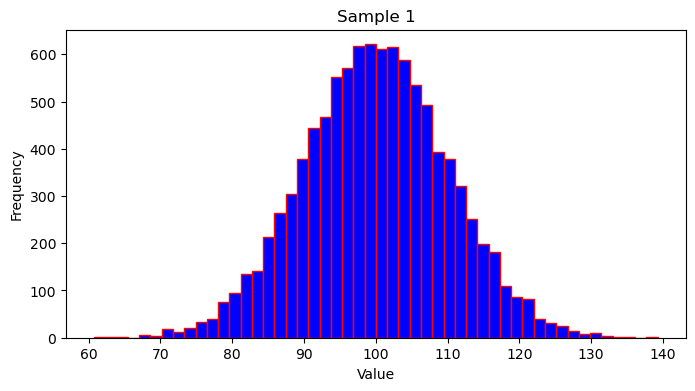

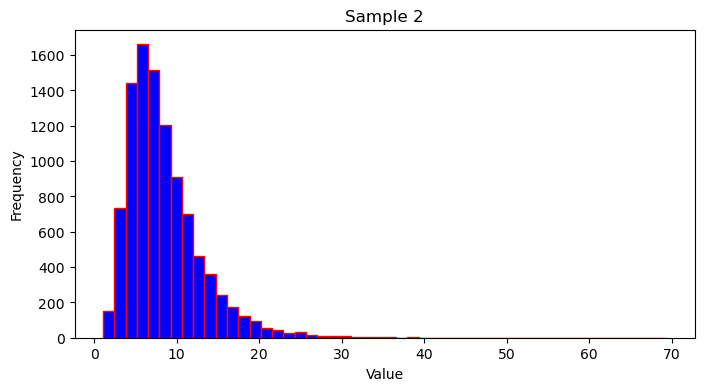

In [35]:
def load_data(url, column):
  
    df = pd.read_csv(url, sep=r"\s+")
    data = np.array(df[column])

    return data

def plot_hist(data, title):  
    plt.figure(figsize=(8, 4))
    plt.hist(data, bins=50, color="blue", edgecolor="red")
    plt.title(title)
    plt.xlabel("Value")
    plt.ylabel("Frequency")

    plt.show()


url1 = "https://github.com/wbandabarragan/physics-teaching-data/raw/refs/heads/main/1D-data/sample1_hres.dat"
url2 = "https://github.com/wbandabarragan/physics-teaching-data/raw/refs/heads/main/1D-data/sample2_hres.dat"

sample1 = load_data(url1, "sample_1")
sample2 = load_data(url2, "sample_2")

plot_hist(sample1, "Sample 1")
plot_hist(sample2, "Sample 2")

## Solution b)

Sample 1 best-fit (mu, sigma): [99.96982005 10.01835301]


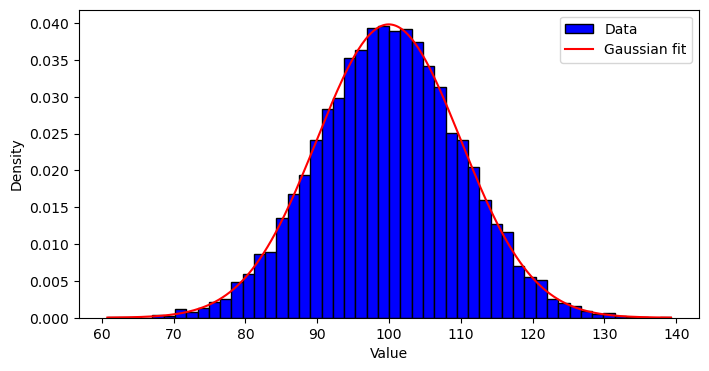

Sample 2 best-fit (A, k, theta): [0.00574779 4.69467406 1.66632236]


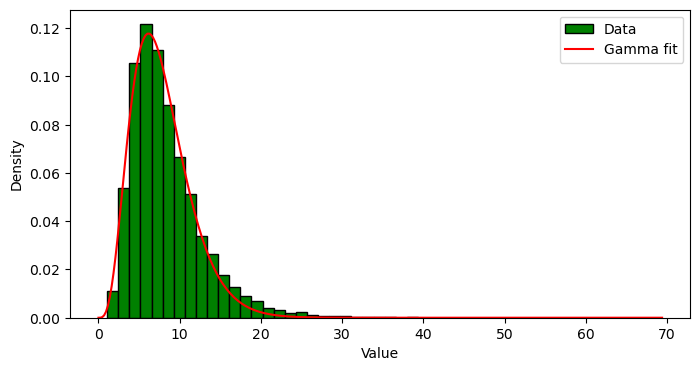

In [38]:

def gaussian_pdf(x, mu, sigma):
    coef_g = 1. / (sigma * np.sqrt(2 * np.pi))
    y = coef_g * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
    return y


#gamma distribution
def gamma_pdf(x, A, k, theta):
    y = A * (x ** (k - 1)) * np.exp(-x / theta)
    return y

#bin centers 
def get_hist_data(data, bins):
    counts, bin_edges = np.histogram(data, bins=bins, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    return bin_centers, counts

#fitting

x1, y1 = get_hist_data(sample1, 50)
coef1, cova1 = opt.curve_fit(gaussian_pdf, x1, y1, p0=[np.mean(sample1), np.std(sample1)])
print("Sample 1 best-fit (mu, sigma):", coef1)

x1_plot = np.linspace(min(sample1), max(sample1), 300)
y1_fit = gaussian_pdf(x1_plot, *coef1)

plt.figure(figsize=(8, 4))
plt.hist(sample1, bins=50, density=True, color="blue", edgecolor="black", label="Data")
plt.plot(x1_plot, y1_fit, color="red", label="Gaussian fit")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.show()


x2, y2 = get_hist_data(sample2, 50)
coef2, cova2 = opt.curve_fit(gamma_pdf, x2, y2, p0=[1, 2, 2])
print("Sample 2 best-fit (A, k, theta):", coef2)

x2_plot = np.linspace(0, max(sample2), 300)
y2_fit = gamma_pdf(x2_plot, *coef2)

plt.figure(figsize=(8, 4))
plt.hist(sample2, bins=50, density=True, color="green", edgecolor="black", label="Data")
plt.plot(x2_plot, y2_fit, color="red", label="Gamma fit")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.show()

## Solution c)

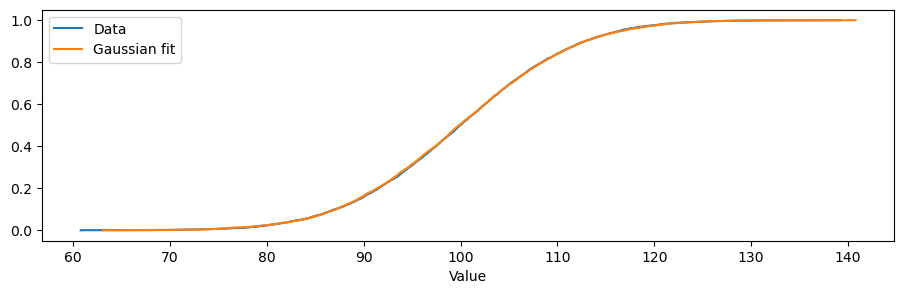

Sample 1 KS value is:  0.0092
Sample 1 p value is:  0.7912059350314521


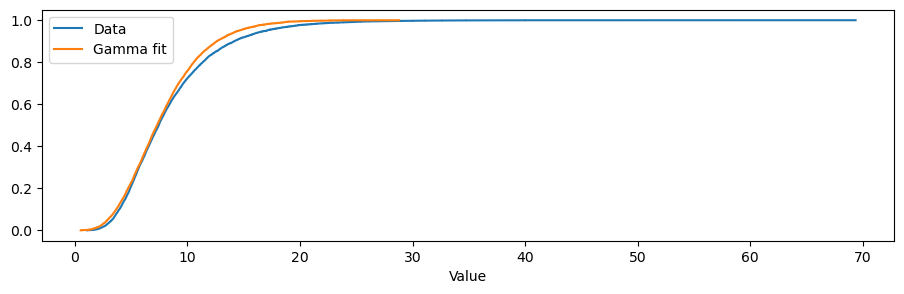

Sample 2 KS value is:  0.0483
Sample 2 p value is:  1.4654857801998744e-10


In [41]:
np.random.seed(77)
fit_sample1 = np.random.normal(coef1[0], coef1[1], size=len(sample1))

# Sort data
sample1_st = np.sort(sample1)
fit1_st = np.sort(fit_sample1)

#values
sample1_cdf = np.arange(1, len(sample1_st) + 1) / len(sample1_st)
fit1_cdf = np.arange(1, len(fit1_st) + 1) / len(fit1_st)

# Plotting
plt.figure(figsize=(11, 3))
plt.step(sample1_st, sample1_cdf, label="Data")
plt.step(fit1_st, fit1_cdf, label="Gaussian fit")
plt.xlabel("Value")
plt.legend()
plt.show()

ks1, p1 = stats.ks_2samp(sample1, fit_sample1)
print("Sample 1 KS value is: ", ks1)
print("Sample 1 p value is: ", p1)


fit_sample2 = np.random.gamma(coef2[1], coef2[2], size=len(sample2))
sample2_st = np.sort(sample2)
fit2_st = np.sort(fit_sample2)

sample2_cdf = np.arange(1, len(sample2_st) + 1) / len(sample2_st)
fit2_cdf = np.arange(1, len(fit2_st) + 1) / len(fit2_st)


plt.figure(figsize=(11, 3))
plt.step(sample2_st, sample2_cdf, label="Data")
plt.step(fit2_st, fit2_cdf, label="Gamma fit")

plt.xlabel("Value")
plt.legend()
plt.show()

#KS test
ks2, p2 = stats.ks_2samp(sample2, fit_sample2)

print("Sample 2 KS value is: ", ks2)
print("Sample 2 p value is: ", p2)

## Solution d)

In [44]:
# Sample 1 

mean1 = np.mean(sample1)
std1 = np.std(sample1)

# Confidence intervals
lower1_1s, upper1_1s = mean1 - 1*std1, mean1 + 1*std1
lower1_2s, upper1_2s = mean1 - 2*std1, mean1 + 2*std1
lower1_3s, upper1_3s = mean1 - 3*std1, mean1 + 3*std1

print("Sample 1 mean: ", mean1)
print("Sample 1 1-sigma interval: ", lower1_1s, "to", upper1_1s)
print("Sample 1 2-sigma interval: ", lower1_2s, "to", upper1_2s)
print("Sample 1 3-sigma interval: ", lower1_3s, "to", upper1_3s)

print("Sample 1 1-sigma error : ", mean1 - lower1_1s, ",", upper1_1s - mean1)


# Sample 2

mean2 = np.mean(sample2)
std2 = np.std(sample2)

# Confidence intervals
lower2_1s, upper2_1s = mean2 - 1*std2, mean2 + 1*std2
lower2_2s, upper2_2s = mean2 - 2*std2, mean2 + 2*std2
lower2_3s, upper2_3s = mean2 - 3*std2, mean2 + 3*std2

print("Sample 2 mean: ", mean2)
print("Sample 2 1-sigma interval: ", lower2_1s, "to", upper2_1s)
print("Sample 2 2-sigma interval: ", lower2_2s, "to", upper2_2s)
print("Sample 2 3-sigma interval: ", lower2_3s, "to", upper2_3s)

print("Sample 2 1-sigma error: ", mean2 - lower2_1s, ",", upper2_1s - mean2)

Sample 1 mean:  99.97864016631574
Sample 1 1-sigma interval:  89.94451810501587 to 110.01276222761561
Sample 1 2-sigma interval:  79.91039604371599 to 120.04688428891549
Sample 1 3-sigma interval:  69.87627398241611 to 130.08100635021538
Sample 1 1-sigma error :  10.034122061299868 , 10.034122061299868
Sample 2 mean:  8.431968609103842
Sample 2 1-sigma interval:  3.9146706300243324 to 12.949266588183352
Sample 2 2-sigma interval:  -0.6026273490551777 to 17.466564567262864
Sample 2 3-sigma interval:  -5.119925328134688 to 21.983862546342372
Sample 2 1-sigma error:  4.51729797907951 , 4.51729797907951


## Solution e)

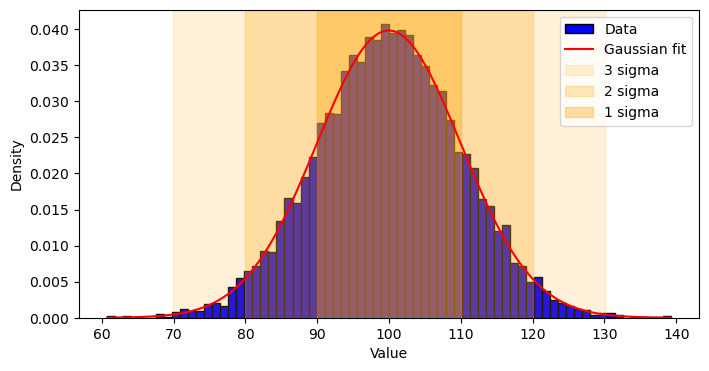

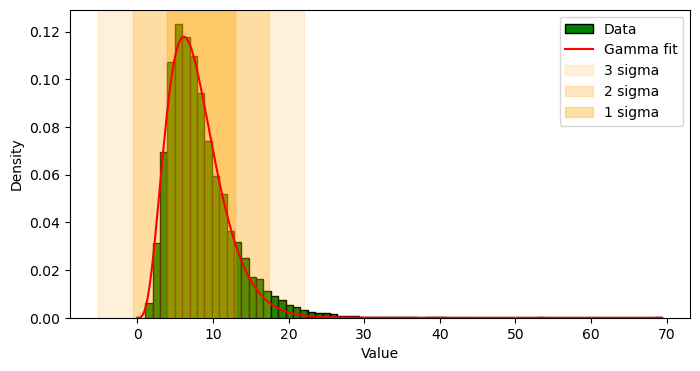

In [47]:
#Sample 1

plt.figure(figsize=(8, 4))

plt.hist(sample1, bins=70, density=True, color="blue", edgecolor="black", label="Data")
plt.plot(x1_plot, y1_fit, color="red", label="Gaussian fit")

plt.axvspan(mean1 - 3*std1, mean1 + 3*std1, color="orange", alpha=0.15, label="3 sigma")
plt.axvspan(mean1 - 2*std1, mean1 + 2*std1, color="orange", alpha=0.25, label="2 sigma")
plt.axvspan(mean1 - 1*std1, mean1 + 1*std1, color="orange", alpha=0.35, label="1 sigma")

plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.show()


# Sample 2

plt.figure(figsize=(8, 4))

plt.hist(sample2, bins=70, density=True, color="green", edgecolor="black", label="Data")
plt.plot(x2_plot, y2_fit, color="red", label="Gamma fit")

plt.axvspan(mean2 - 3*std2, mean2 + 3*std2, color="orange", alpha=0.15, label="3 sigma")
plt.axvspan(mean2 - 2*std2, mean2 + 2*std2, color="orange", alpha=0.25, label="2 sigma")
plt.axvspan(mean2 - 1*std2, mean2 + 1*std2, color="orange", alpha=0.35, label="1 sigma")

plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.show()

## Solution f)

Sample 2's model (Gamma) is rejected, its p-value (≈1.47×10⁻¹⁰) is much smaller than 0.05, the rule 'reject if p < 0.05' applies, meaning the Gamma distribution does not correctly represent the data. 
Sample 1's model (Gaussian), has a p-value (0.79) greater than 0.05, so it is not rejected the Gaussian distribution correctly represents the data.

## Solution g)

For Sample 1, the 1σ/2σ/3σ bands represent the real data spread, so they actually represent the expected 68/95/99.7% well. 

For Sample 2, those same symmetric bands don't fit as well, the lower edge stretches into a region with barely any data while the upper side doesn't fully capture the long tail where data still exists. Basically, mean ± nσ works great for symmetric data but breaks down for skewed data.

# Problem 3. Data I/O and regression: $\rm CO_2$ concentrations

This problem consists of reading, displaying, analysing, and modelling $\rm CO_2$ concentration data from a monitoring station located in Kennaook/Cape Grim, Australia.

The data files for this exercise were downloaded from the CSIRO site:

https://www.csiro.au/en/research/natural-environment/atmosphere/Latest-greenhouse-gas-data

For this problem, you will use the following CSV file:

https://github.com/wbandabarragan/physics-teaching-data/blob/main/1D-data/CapeGrim_CO2_data_2025.csv


### Coding Tasks:

#### Basic I/O:

**(a)** Inspect the structure of the file. Then, create a python function that uses **pandas** to read in the **CapeGrim_CO2_data_2025.csv** file, skips the header, place the data into a pandas dataframe, and returns 3 columns as arrays, namely: "DATE", "CO2(ppm)", "SD(ppm)". The first one has the data collection times, the second one contains $\rm CO_2$ concentrations in $\rm ppm$, and the third one has the respective instrumental standard deviations also in $\rm ppm$.

**(b)** Now, you will rescale the uncertainties to more realistic values by multiplying the instrumental standard deviation by $10$, so $\sigma=10\,\sigma_{\rm instrumental}$. The instrumental uncertainties are very small, and there are unaccounted-for errors, such as systematic errors. A factor of $\sim 10$ is a fine estimate for this data set.

**(c)** Make a high-quality, labeled plot of the $\rm CO_2$ concentrations (in $\rm ppm$) versus time, including the y-error bars equal to the uncertainties calculated in (b).

**(d)** How monotonic and linear is the relation between the two variables?

#### Regressions and goodness-of-fit tests:

**(e)** Now, you will carry out a regression on the data, assuming a simple linear regression model (**"Model 1"**) with 2 free parameters. Carry out a $\chi^2$ minimisation, and report the resulting equation and figure. The figure should have a high-quality, labeled plot of the original data with error bars and the resulting best-fit line.

**(f)** To perform a goodness-of-fit test, create a python function that calculates the global $\chi^2$ statistic, the number of degrees of freedom, and the reduced $\chi^2$ statistic. 

**(g)** Next, you can propose your own model (**"Model 2"**) for the data. Motivate and write down your model. Then, repeat steps (e) and (f) for your model and report the results, including the reduced $\chi^2$ statistic. **Hint:** Keep the model simple with maximum 2 free parameters and avoid overfitting.

#### Confidence intervals:

**(h)** Finally, you will construct **2D confidence intervals** using the $\chi^2$ statistic evaluated in the vicinity of the best-fit values for the free parameters of Models 1 and 2. Since both models have two free parameters, you should create python functions that compute and return the 2D $\chi^2$ surface of each model onto the respective parameter space. **Hints:** to create a 2D parameter space as a meshgrid, you should first create vectors with numbers around the best-fit values found in your regressions. 1D plots showing $\chi^2$ as a function of each parameter may help identify optimal numbers.

**(i)** Make a high-quality, labeled, multi-panel figure showing the 2D $\chi^2$ surface of each model: first in 3D, and then in projection with a marker showing the minimum and overimposed contours indicating at least three confidence levels. **Hint:** the maps should have one of the free parameters in the X axis, the other free parameter in the Y axis, and the $\chi^2$ surface in the Z axis.

### Analysis questions:

**(j)** Compare the $\chi^2$ statistic of models 1 and 2. Which model is better? Model 1 or model 2? Why?

**(k)** Briefly comment the results in (i) highlighting the differences between the confidence intervals of both models. What do these confidence intervals tell us? 

## SOLUTION

## Solution a)

In [56]:
def io_data(filename):

    df = pd.read_csv(filename, skiprows=24)

    DATE = np.array(df["DATE"])
    CO2 = np.array(df["CO2(ppm)"])
    SD = np.array(df["SD(ppm)"])

    return DATE, CO2, SD


fname = "https://github.com/wbandabarragan/physics-teaching-data/raw/refs/heads/main/1D-data/CapeGrim_CO2_data_2025.csv"

date, ppmCO2, ppmSD = io_data(fname)

print("dates", date[:5])
print("CO2", ppmCO2[:5])
print("ERRORS", ppmSD[:5])

dates [1976.3689 1976.4536 1976.5355 1976.6202 1976.7049]
CO2 [328.861 328.988 329.653 330.55  330.872]
ERRORS [0.165 0.285 0.282 0.201 0.234]


## Solution b)


In [59]:
sd_scaled = 10 * ppmSD

#print("Scaled SD:", sd_scaled[:5])

## Solution c)

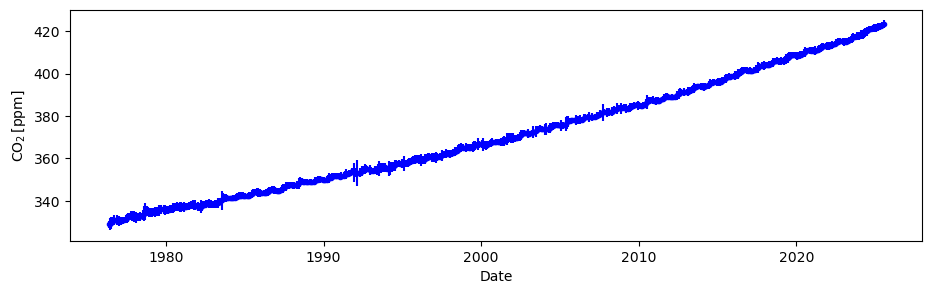

In [62]:
plt.figure(figsize=(11, 3))

plt.errorbar(date, ppmCO2, sd_scaled, 0, marker=".", linestyle=" ", color="blue")

plt.xlabel("Date")
plt.ylabel(r"$\rm CO_2\,[ppm]$")

plt.show()

## Solution d)

CO2 concentrations at Cape Grim have been rising over time, so the relationship between date and CO2 is monotonic, nearly every later date has a higher CO2 value than an earlier one. As for linearity, it's close to a straight line, real CO2 growth accelerates slightly over the decades (due to rising emissions), so a straight line is a decent approximation.

## Solution e)

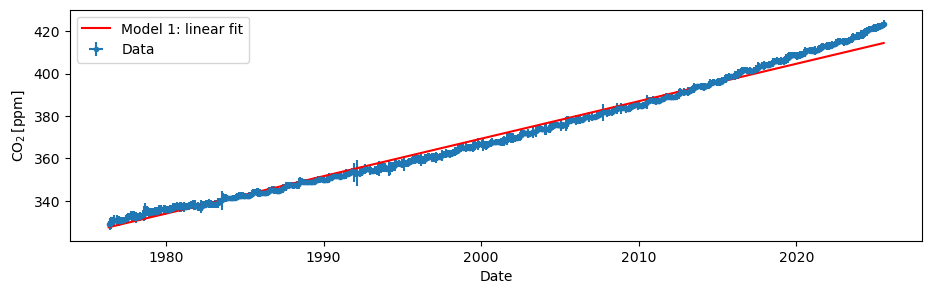

CO2 = 1.76704 * date + -3164.77420
BFP: [ 1.76703698e+00 -3.16477420e+03]


In [67]:
def linear_model(x, m, b):
    y = m*x + b
    return y

coef1, cova1 = opt.curve_fit(linear_model, date, ppmCO2, sigma=sd_scaled)
co2_fit1 = linear_model(date, *coef1)

plt.figure(figsize=(11, 3))
plt.errorbar(date, ppmCO2, sd_scaled, 0, marker=".", linestyle=" ", label="Data")
plt.plot(date, co2_fit1, color="red", label="Model 1: linear fit")

plt.xlabel("Date")
plt.ylabel(r"$\rm CO_2\,[ppm]$")
plt.legend()
plt.show()

#plt.savefig("linearmodel.svg")
print('CO2 = %.5f * date + %.5f' % (coef1[0], coef1[1]))
print("BFP:", coef1)


## Solution f)

In [70]:
def chi_sqr_stat(y_data, y_model, sigma):
    chi_sqr = np.sum(((y_data - y_model) / sigma)**2)
    return chi_sqr

chi1 = chi_sqr_stat(ppmCO2, co2_fit1, sd_scaled)
nu1 = len(ppmCO2) - len(coef1)
red_chi1 = chi1 / nu1

print("chi^2 for M1:", chi1)
print("Degrees of freedom:", nu1)
print("Reduced chi^2:", red_chi1)

chi^2 for M1: 2712.2379951788794
Degrees of freedom: 589
Reduced chi^2: 4.604818327977724


## Solution g)

Best-fit parameters: [3.70054513e+02 4.85365286e-03]


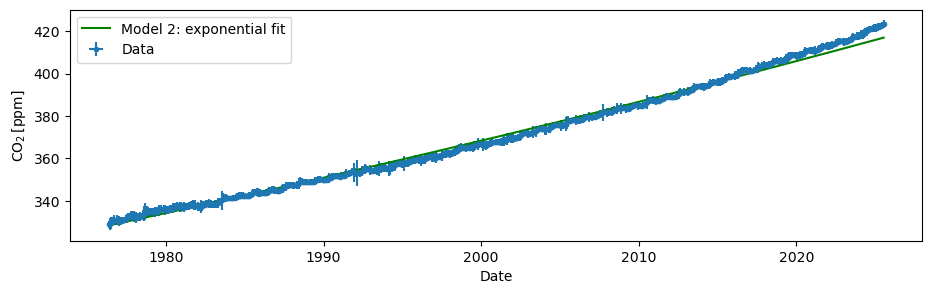

CO2 = 370.05451 * exp(0.00485 * (date - mean_date))
chi^2 for Model 2: 1378.0861050427375
Degrees of freedom: 589
Reduced chi^2 for Model 2: 2.3397047623815577


In [73]:
date_shift = date - np.mean(date)

def exp_model(x, A, B):
    y = A * np.exp(B*x)
    return y


coef2, cova2 = opt.curve_fit(exp_model, date_shift, ppmCO2, sigma=sd_scaled, p0=[400, 0.01])
print("Best-fit parameters:", coef2)

co2_fit2 = exp_model(date_shift, *coef2)

plt.figure(figsize=(11, 3))

plt.errorbar(date, ppmCO2, sd_scaled, 0, marker=".", linestyle=" ", label="Data")
plt.plot(date, co2_fit2, color="green", label="Model 2: exponential fit")

plt.xlabel("Date")
plt.ylabel(r"$\rm CO_2\,[ppm]$")

plt.legend()
plt.show()

print('CO2 = %.5f * exp(%.5f * (date - mean_date))' % (coef2[0], coef2[1]))


chi2 = chi_sqr_stat(ppmCO2, co2_fit2, sd_scaled)
nu2 = len(ppmCO2) - len(coef2)
red_chi2 = chi2 / nu2

print("chi^2 for Model 2:", chi2)
print("Degrees of freedom:", nu2)
print("Reduced chi^2 for Model 2:", red_chi2)

## Solution h)

In [76]:
m_vals1 = np.linspace(coef1[0]*0.9, coef1[0]*1.1, 100)
b_vals1 = np.linspace(coef1[1]*0.9, coef1[1]*1.1, 100)

M1, B1 = np.meshgrid(m_vals1, b_vals1)


def chi2_surface_model1(M, B):

    chi_surf = np.zeros(M.shape)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            y_model = linear_model(date, M[i, j], B[i, j])
            chi_surf[i, j] = chi_sqr_stat(ppmCO2, y_model, sd_scaled)

    return chi_surf

chi_surf1 = chi2_surface_model1(M1, B1)


# Vectors

A_vals2 = np.linspace(coef2[0]*0.9, coef2[0]*1.1, 100)
B_vals2 = np.linspace(coef2[1]*0.9, coef2[1]*1.1, 100)

A2, B2 = np.meshgrid(A_vals2, B_vals2)


def chi2_surface_model2(A, B):
    chi_surf = np.zeros(A.shape)

    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            y_model = exp_model(date_shift, A[i, j], B[i, j])
            chi_surf[i, j] = chi_sqr_stat(ppmCO2, y_model, sd_scaled)

    return chi_surf

chi_surf2 = chi2_surface_model2(A2, B2)

## Solution i)

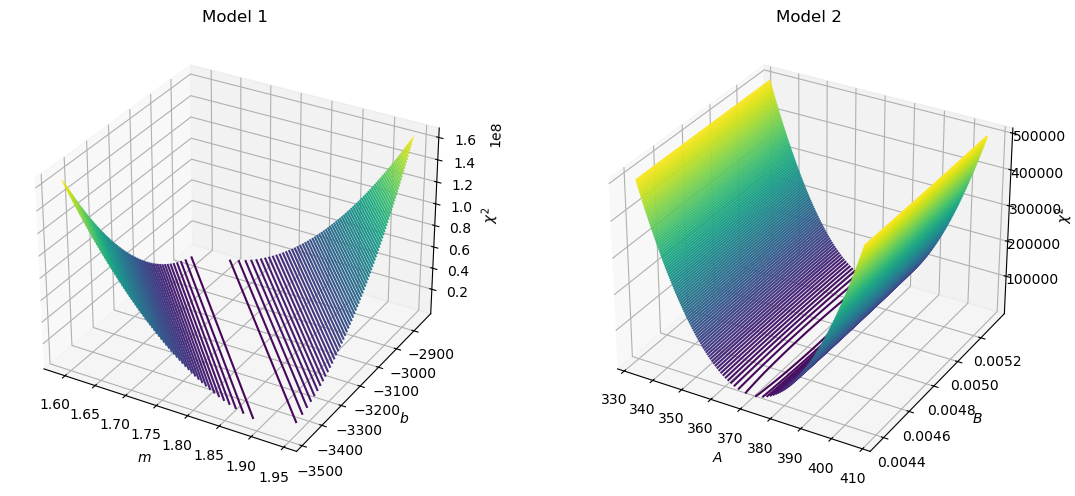

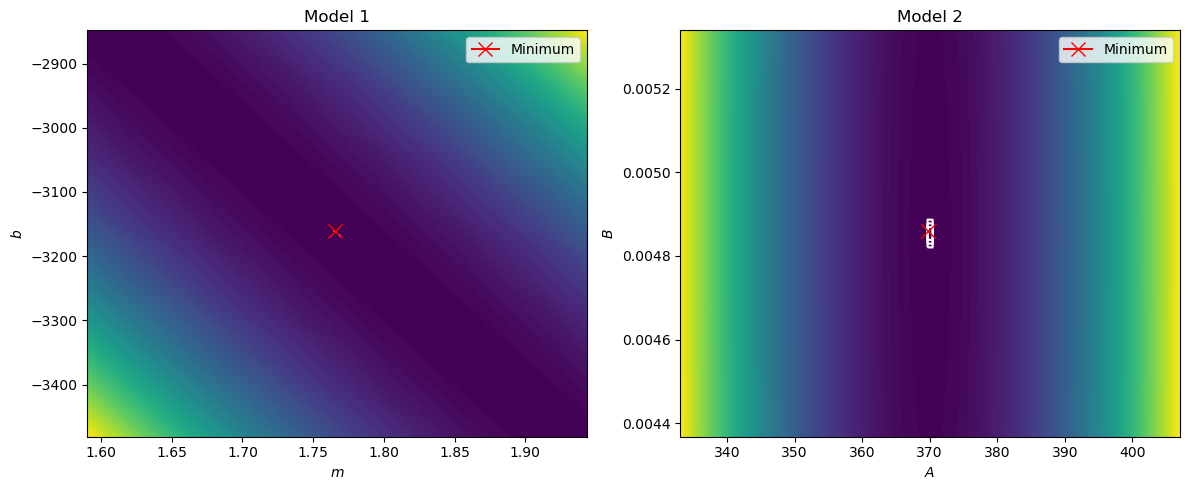

In [79]:
plt.close('all')

#minimum point

min1_idx = np.unravel_index(np.argmin(chi_surf1), chi_surf1.shape)
min1_m = M1[min1_idx]
min1_b = B1[min1_idx]
chi_min1 = chi_surf1[min1_idx]

min2_idx = np.unravel_index(np.argmin(chi_surf2), chi_surf2.shape)
min2_A = A2[min2_idx]
min2_B = B2[min2_idx]
chi_min2 = chi_surf2[min2_idx]

levels1 = chi_min1 + np.array([2.3, 6.17, 11.8])
levels2 = chi_min2 + np.array([2.3, 6.17, 11.8])


#1 figure

fig = plt.figure(figsize=(12, 5))

ax = plt.subplot(1, 2, 1, projection="3d")
ax.contour3D(M1, B1, chi_surf1, 100)
ax.set_title("Model 1")
ax.set_xlabel(r"$m$")
ax.set_ylabel(r"$b$")
ax.set_zlabel(r"$\chi^2$")

ax = plt.subplot(1, 2, 2, projection="3d")
ax.contour3D(A2, B2, chi_surf2, 100)
ax.set_title("Model 2")
ax.set_xlabel(r"$A$")
ax.set_ylabel(r"$B$")
ax.set_zlabel(r"$\chi^2$")


#plt.savefig("3d-Models.svg")
plt.tight_layout()
plt.show()


#2 figure
fig = plt.figure(figsize=(12, 5))

ax = plt.subplot(1, 2, 1)
ax.contourf(M1, B1, chi_surf1, 100)
ax.contour(M1, B1, chi_surf1, levels=levels1, colors="white")
ax.plot(min1_m, min1_b, marker="x", color="red", markersize=10, label="Minimum")
ax.set_title("Model 1")
ax.set_xlabel(r"$m$")
ax.set_ylabel(r"$b$")
ax.legend()

ax = plt.subplot(1, 2, 2)
ax.contourf(A2, B2, chi_surf2, 100)
ax.contour(A2, B2, chi_surf2, levels=levels2, colors="white")
ax.plot(min2_A, min2_B, marker="x", color="red", markersize=10, label="Minimum")
ax.set_title("Model 2")
ax.set_xlabel(r"$A$")
ax.set_ylabel(r"$B$")
ax.legend()

#plt.savefig("2d-Models.svg")
plt.tight_layout()
plt.show()

## Solution j)

Model 2 is the better model, its reduced chi² (2.34) is much closer to 1 than Model 1's (4.60), CO2 growth isn't perfectly linear, it speeds up over time as emissions rise, so Model 1 systematically misses that curvature while Model 2 captures it. 

## Solution k)

Model 1's confidence region is elongated and tilted slope and intercept trade off against each other. Model 2's region is more compact and rounder, meaning A and B are better constrained and less degenerate. This also tracks with Model 2's lower chi²: tighter contours mean less room to shift the parameters before the fit gets noticeably worse.